<a href="https://colab.research.google.com/github/sousadevelop/data-analysis-instagram-engagement/blob/main/data-analysis-instagram-engagement-part02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisando o engajamento do Instagram - Foco em Tags

### O que queremos responder?
- Qual tipo de conteúdo **mais engaja** no Instagram da minha empresa?
<br><br>
- Temos a base de dados do Instagram **desde que o usuário começou a postar na marca até o dia 27/março**
<br><br>
- Ele também dá alguns direcionamentos:
    - Podem ignorar a coluna visualizações, queremos entender apenas curtidas, comentários e interações
    - Tags vazias é que realmente não possuem tag (favor tratar como vazio)

### Vamos importar e visualizar a nossa base

In [1]:
# Importando o pandas
import pandas as pd

In [2]:
# Importar a base em excel
# - Base: 08. Analisando o engajamento no Instagram.xlsx

df = pd.read_excel("08. Analisando o engajamento no Instagram.xlsx")

In [3]:
# Visualizando as 5 primeiras linhas
df.head()

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,NaN,Loja,N,N,NaN,2874
1,Foto,2021-09-11,2930,28,NaN,Loja/Produtos,N,N,NaN,2958
2,Foto,2021-09-11,2807,9,NaN,Loja,N,N,NaN,2816
3,Vídeo,2021-09-12,5115,49,82878.0,Produtos,N,N,NaN,5164
4,Foto,2021-09-13,4392,45,NaN,Produtos,S,N,NaN,4437


In [4]:
# Agrupamento por tags
df.groupby("Tags")["Curtidas"].mean()

,Curtidas
Tags,
Datas comemorativas,17975.000000
Datas comemorativas/Promoções,29084.000000
Dicas de como usar/Novos Produtos,5703.500000
Dicas de como usar/Produtos,7586.666667
Influenciadores,15197.285714
Loja,2832.500000
Loja/Produtos,2930.000000
Novos Produtos,11619.571429
Produtos,5666.916667


### Como conseguir analisar separadamente as tags, podemos dividir linhas com 2 tags em 2 linhas

Para conseguir analisar separadamente as tags, podemos dividir linhas com 2 tags em 2 linhas.

* Para isso primeiro vamos usar o split para separar em uma lista com as tags
* Depois vamos usar o explode para transformar as listas com 2 tags em 2 linhas diferentes

O split separa um texto em uma lista baseado em algum separador.

In [5]:
texto = "O Curso de Ciência de Dados da Hashtag é top!"

In [6]:
# Se eu não passo nenhum argumento, ele vai separar por espaço
texto.split()

['O', 'Curso', 'de', 'Ciência', 'de', 'Dados', 'da', 'Hashtag', 'é', 'top!']

In [7]:
texto = "O-Curso-de-Ciência-de-Dados-da-Hashtag-é-top!"

In [8]:
# Se eu não passo nenhum argumento, ele vai separar por espaço
texto.split()

['O-Curso-de-Ciência-de-Dados-da-Hashtag-é-top!']

In [9]:
# Se for outro delimitador, eu preciso informar
texto.split("-")

['O', 'Curso', 'de', 'Ciência', 'de', 'Dados', 'da', 'Hashtag', 'é', 'top!']

In [10]:
# Vamos usar isso para a nossa coluna "Tags"
# Transformando a coluna Tags em uma lista de tags
df.Tags = df.Tags.str.split("/")
df.head()

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,NaN,[Loja],N,N,NaN,2874
1,Foto,2021-09-11,2930,28,NaN,"[Loja, Produtos]",N,N,NaN,2958
2,Foto,2021-09-11,2807,9,NaN,[Loja],N,N,NaN,2816
3,Vídeo,2021-09-12,5115,49,82878.0,[Produtos],N,N,NaN,5164
4,Foto,2021-09-13,4392,45,NaN,[Produtos],S,N,NaN,4437


### O explode vai separar uma coluna de um DataFrame em 1 linha para cada elemento da lista

In [11]:
# Criando o dicionários
dic = {
    "A": [[1,2],3,[4,5,6],[]],
    "B": [1,2,3,4],
}

In [12]:
# Transformando esse dicionário em um DataFrame
base_dic = pd.DataFrame(dic)

base_dic

,A,B
0,"[1, 2]",1
1,3,2
2,"[4, 5, 6]",3
3,[],4


In [13]:
# Usando o explode para separar a coluna A
base_dic = base_dic.explode('A')
base_dic

,A,B
0,1,1
0,2,1
1,3,2
2,4,3
2,5,3
2,6,3
3,NaN,4


* Tudo que estiver em lista será separado em 1 linha por elemento da lista
* Se não tiver na lista, o elemento será mantido
* Listas vazias vão ter o valor de NaN

* Para as outras colunas, elas irão repetir os seus valores
* Inclusive o índice também irá repetir

In [14]:
# Separando a coluna Tag em 1 linha para cada elemento da lista
df = df.explode('Tags')
df.head()

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,NaN,Loja,N,N,NaN,2874
1,Foto,2021-09-11,2930,28,NaN,Loja,N,N,NaN,2958
1,Foto,2021-09-11,2930,28,NaN,Produtos,N,N,NaN,2958
2,Foto,2021-09-11,2807,9,NaN,Loja,N,N,NaN,2816
3,Vídeo,2021-09-12,5115,49,82878.0,Produtos,N,N,NaN,5164


### Fazendo a mesma análise da média por tag

**Aviso importante: muito cuidado pois as outras colunas serão duplicadas, então não podemos fazer o mesmo cálculo de média que estávamos fazendo**

* No arquivo anterior:

**Podemos então fazer os agrupamentos que acharmos melhor para entender os nossos dados**

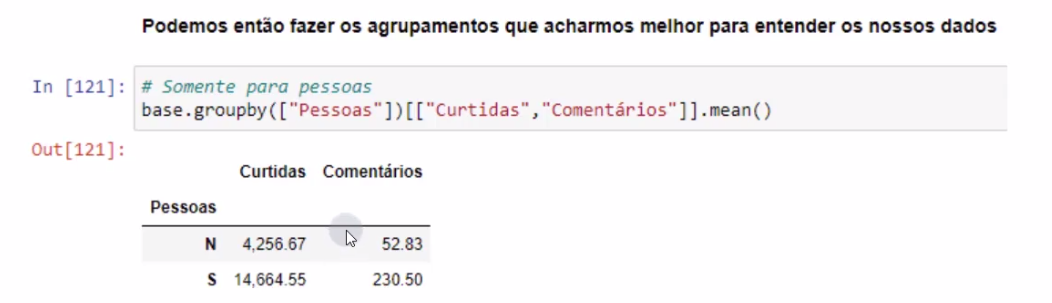

### Depois de usar a função explode() só devemos fazer análise envolvendo tags

In [15]:
df.groupby("Tags")["Curtidas"].mean()

,Curtidas
Tags,
Datas comemorativas,20752.250000
Dicas de como usar,6833.400000
Influenciadores,15197.285714
Loja,2865.000000
Novos Produtos,10304.888889
Produtos,6269.823529
Promoções,27458.333333
Trends,20024.000000


In [16]:
# Ordenando por curtidas
df.groupby("Tags")[["Curtidas","Comentários"]].mean().sort_values("Curtidas",ascending=False)

,Curtidas,Comentários
Tags,,
Promoções,27458.333333,531.000000
Datas comemorativas,20752.250000,343.500000
Trends,20024.000000,352.250000
Influenciadores,15197.285714,161.714286
Novos Produtos,10304.888889,198.555556
Dicas de como usar,6833.400000,133.600000
Produtos,6269.823529,94.117647
Loja,2865.000000,17.666667


* **Postagens de promoções são as que mais engajam.**
* **Além de promoções, datas comemorativas e trends também possuem um ótimo engajamento.**

## Agora irei validar os valores sem Tags

In [17]:
# Filtrando valores sem tags
df[df.Tags.isnull()]

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
11,Foto,2021-10-12,17831,391,NaN,NaN,S,S,NaN,18222
19,Foto,2021-12-12,16086,268,NaN,NaN,S,S,NaN,16354
29,Foto,2022-01-19,8612,142,NaN,NaN,S,N,NaN,8754
38,Foto,2022-02-15,17687,213,NaN,NaN,S,N,NaN,17900
41,Foto,2022-02-22,12530,90,NaN,NaN,S,N,NaN,12620
43,Foto,2022-03-04,24399,266,NaN,NaN,S,S,NaN,24665
49,Foto,2022-03-22,9087,106,NaN,NaN,S,S,NaN,9193
50,Foto,2022-03-26,16551,186,NaN,NaN,S,N,NaN,16737


In [18]:
# Atribuindo o texto "sem tag" para os valores da coluna Tag onde estão como NaN
df.loc[df.Tags.isnull(),"Tags"] = "Sem tag"

In [19]:
# Monstrando a tabela com os valores atualizados sem tags
df.groupby("Tags")[["Curtidas","Comentários"]].mean().sort_values("Curtidas",ascending=False)

,Curtidas,Comentários
Tags,,
Promoções,27458.333333,531.000000
Datas comemorativas,20752.250000,343.500000
Trends,20024.000000,352.250000
Sem tag,15347.875000,207.750000
Influenciadores,15197.285714,161.714286
Novos Produtos,10304.888889,198.555556
Dicas de como usar,6833.400000,133.600000
Produtos,6269.823529,94.117647
Loja,2865.000000,17.666667


## Analisarei agora a relação das Tags com pessoas e campanhas

In [20]:
# Validando com Pessoas e Tags
df.groupby(["Pessoas", "Tags"])[["Curtidas","Comentários"]].mean()

Curtidas  Comentários
Pessoas Tags                                          
N       Loja                  2865.000000    17.666667
        Novos Produtos        5359.000000    62.000000
        Produtos              4450.666667    60.777778
S       Datas comemorativas  20752.250000   343.500000
        Dicas de como usar    6833.400000   133.600000
        Influenciadores      15197.285714   161.714286
        Novos Produtos       10923.125000   215.625000
        Produtos              8316.375000   131.625000
        Promoções            27458.333333   531.000000
        Sem tag              15347.875000   207.750000
        Trends               20024.000000   352.250000

In [21]:
# Ordenando por curtidas
df.groupby(["Pessoas", "Tags"])[["Curtidas","Comentários"]].mean().sort_values("Curtidas", ascending=False)

Curtidas  Comentários
Pessoas Tags                                          
S       Promoções            27458.333333   531.000000
        Datas comemorativas  20752.250000   343.500000
        Trends               20024.000000   352.250000
        Sem tag              15347.875000   207.750000
        Influenciadores      15197.285714   161.714286
        Novos Produtos       10923.125000   215.625000
        Produtos              8316.375000   131.625000
        Dicas de como usar    6833.400000   133.600000
N       Novos Produtos        5359.000000    62.000000
        Produtos              4450.666667    60.777778
        Loja                  2865.000000    17.666667

In [22]:
# Fazendo para campanhas e tags
df.groupby(["Campanhas", "Tags"])[["Curtidas","Comentários"]].mean().sort_values("Curtidas", ascending=False)

Curtidas  Comentários
Campanhas Tags                                          
S         Promoções            33217.500000   490.500000
          Trends               22400.666667   386.666667
          Datas comemorativas  20752.250000   343.500000
          Influenciadores      18715.400000   197.600000
          Sem tag              16850.750000   257.750000
N         Promoções            15940.000000   612.000000
          Sem tag              13845.000000   157.750000
          Trends               12894.000000   249.000000
S         Novos Produtos       11040.666667   323.000000
N         Novos Produtos        9937.000000   136.333333
S         Produtos              9074.000000    67.500000
N         Dicas de como usar    6833.400000   133.600000
          Influenciadores       6402.000000    72.000000
          Produtos              5895.933333    97.666667
          Loja                  2865.000000    17.666667

## Conclusões

* Ter o rosto de outras pessoas é fundamental para um bom engajamento na publicação

  * Em todas as tags, quando havia o rosto, o resultado foi muito melhor

* Criar campanhas ajuda muito na divulgação da marca

* Promoções tiveram um desempenho absurdamente maior que qualquer outra tag

  * Porém é uma tag que pode ter custo para a loja, o que deve ser analisado

* Usar conteúdos que estão em trend também ajudam na divulgação da marca, mesmo a trend sendo de outros nichos

* A melhor maneira de mostrar produtos é através de outras pessoas utilizando-os, e se possível em campanhas de datas especiais

* Para novos produtos a inclusão de pessoas é mais crítica ainda, sendo quase o dobro quando há um rosto junto ao produto

* Não podemos afirmar que a tag `Loja` é ruim até testarmos essa tag incluindo pessoas ou em uma campanha. Vale o teste para verificar

* Continuaremos a monitorar as postagens para encontrar novos padrões dado que ainda temos poucas informações da base
